## Part A - Dataset cleaning and preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
# Load the Excel file into a pandas DataFrame
file_name = "https://raw.githubusercontent.com/janloke7/OMIS3020-Group-7/main/ttc-bus-delay-data-2023.xlsx"
df = pd.read_excel(file_name)

In [3]:
# Display the first 5 rows and information about the DataFrame
display(df.head())
print(df.info())
print(df.shape)

,Date,Route,Time,Day,Location,Incident,Min Delay,Min Gap,Direction,Vehicle
0,2023-01-01,91,02:30,Sunday,WOODBINE AND MORTIMER,Diversion,81,111,NaN,8772
1,2023-01-01,69,02:34,Sunday,WARDEN STATION,Security,22,44,S,8407
2,2023-01-01,35,03:06,Sunday,JANE STATION,Cleaning - Unsanitary,30,60,N,1051
3,2023-01-01,900,03:14,Sunday,KIPLING STATION,Security,17,17,NaN,3334
4,2023-01-01,85,03:43,Sunday,MEADOWALE LOOP,Security,1,1,NaN,1559


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50913 entries, 0 to 50912
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       50913 non-null  datetime64[ns]
 1   Route      50385 non-null  object        
 2   Time       50913 non-null  object        
 3   Day        50913 non-null  object        
 4   Location   50913 non-null  object        
 5   Incident   50913 non-null  object        
 6   Min Delay  50913 non-null  int64         
 7   Min Gap    50913 non-null  int64         
 8   Direction  42138 non-null  object        
 9   Vehicle    50913 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 3.9+ MB
None
(50913, 10)


### Data Cleaning Steps

Perform the following data cleaning and preparation steps:
1. Convert 'Time' column to datetime format.
2. Convert 'Vehicle' column to object/string type.
3. Check for and remove duplicate records.
4. Check for and handle null values.

In [4]:
# 1. Convert 'Time' column to datetime format
# Check if 'Date' column exists. If so, combine 'Date' and 'Time' to create a full 'DateTime' object.

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time
    # Convert 'Time' column (e.g., 'HH:MM') to datetime.time objects
    df['DateTime'] = df.apply(lambda row: row['Date'].replace(hour=row['Time'].hour, minute=row['Time'].minute, second=row['Time'].second), axis=1)
    # Combine 'Date' (datetime) and 'Time' (time object) to create a full 'DateTime' column

    print("Converted 'Time' to time objects and created combined 'DateTime' column.")

elif 'Time' in df.columns:
    # If only 'Time' exists, convert it to datetime (will have a default date)
    # Adjust format to match 'HH:MM'
    df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time
    print("Converted 'Time' column to time objects.")

else:
    print("Neither 'Date' nor 'Time' column found for conversion.")

df.drop(columns=['Date', 'Time'], inplace=True)
  # Drop the original 'Date' and 'Time' columns

Converted 'Time' to time objects and created combined 'DateTime' column.


In [5]:
# 2. Convert 'Vehicle' column to object/string type
if 'Vehicle' in df.columns:
    df['Vehicle'] = df['Vehicle'].astype(str)
    print("Converted 'Vehicle' column to object type.")
else:
    print("'Vehicle' column not found.")

print('\nDataFrame Info after type conversions:')
print(df.info())

Converted 'Vehicle' column to object type.

DataFrame Info after type conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50913 entries, 0 to 50912
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Route      50385 non-null  object        
 1   Day        50913 non-null  object        
 2   Location   50913 non-null  object        
 3   Incident   50913 non-null  object        
 4   Min Delay  50913 non-null  int64         
 5   Min Gap    50913 non-null  int64         
 6   Direction  42138 non-null  object        
 7   Vehicle    50913 non-null  object        
 8   DateTime   50913 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 3.5+ MB
None


In [6]:
# 3. Handle duplicate records
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicate_rows_removed = initial_rows - df.shape[0]
print(f"Removed {duplicate_rows_removed} duplicate rows.")

Removed 187 duplicate rows.


In [7]:
# 4. Handle null values
print('\nMissing values before handling:')
print(df.isnull().sum())

# For simplicity, we will fill numerical NaNs with 0 and categorical NaNs with 'Unknown'
# A more sophisticated approach might involve imputation or dropping rows/columns based on context.

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Fill NaN values
for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(0, inplace=True)
        print(f"Filled NaN in numerical column '{col}' with 0.")

for col in categorical_cols:
    if df[col].isnull().any():
        df[col].fillna('Unknown', inplace=True)
        print(f"Filled NaN in categorical column '{col}' with 'Unknown'.")

print('\nMissing values after handling:')
print(df.isnull().sum())


Missing values before handling:
Route         528
Day             0
Location        0
Incident        0
Min Delay       0
Min Gap         0
Direction    8758
Vehicle         0
DateTime        0
dtype: int64
Filled NaN in categorical column 'Route' with 'Unknown'.
Filled NaN in categorical column 'Direction' with 'Unknown'.

Missing values after handling:
Route        0
Day          0
Location     0
Incident     0
Min Delay    0
Min Gap      0
Direction    0
Vehicle      0
DateTime     0
dtype: int64


/tmp/ipykernel_430/1263509954.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [8]:
print(numerical_cols)
print(categorical_cols)

Index(['Min Delay', 'Min Gap'], dtype='object')
Index(['Route', 'Day', 'Location', 'Incident', 'Direction', 'Vehicle'], dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50726 entries, 0 to 50912
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Route      50726 non-null  object        
 1   Day        50726 non-null  object        
 2   Location   50726 non-null  object        
 3   Incident   50726 non-null  object        
 4   Min Delay  50726 non-null  int64         
 5   Min Gap    50726 non-null  int64         
 6   Direction  50726 non-null  object        
 7   Vehicle    50726 non-null  object        
 8   DateTime   50726 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 3.9+ MB


In [10]:
# Display the first few rows of the cleaned data
print('\nFirst 5 rows of cleaned data:')
display(df.head())


First 5 rows of cleaned data:


,Route,Day,Location,Incident,Min Delay,Min Gap,Direction,Vehicle,DateTime
0,91,Sunday,WOODBINE AND MORTIMER,Diversion,81,111,Unknown,8772,2023-01-01 02:30:00
1,69,Sunday,WARDEN STATION,Security,22,44,S,8407,2023-01-01 02:34:00
2,35,Sunday,JANE STATION,Cleaning - Unsanitary,30,60,N,1051,2023-01-01 03:06:00
3,900,Sunday,KIPLING STATION,Security,17,17,Unknown,3334,2023-01-01 03:14:00
4,85,Sunday,MEADOWALE LOOP,Security,1,1,Unknown,1559,2023-01-01 03:43:00


NOTE: For 'Route' (528 missing values, ~1% of data): Since this is a small percentage, we are simply dropping the rows where 'Route' is missing. This ensures that every entry has a valid route, which could be important for the model.

In [11]:
# Identify rows where 'Route' is 'Unknown'
unknown_route_rows = df[df['Route'] == 'Unknown'].shape[0]

# Drop rows where 'Route' is 'Unknown'
df = df[df['Route'] != 'Unknown']

print(f"Removed {unknown_route_rows} rows where 'Route' was 'Unknown'.")
print('\nDataFrame Info after dropping "Unknown" routes:')
print(df.info())

Removed 528 rows where 'Route' was 'Unknown'.

DataFrame Info after dropping "Unknown" routes:
<class 'pandas.core.frame.DataFrame'>
Index: 50198 entries, 0 to 50912
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Route      50198 non-null  object        
 1   Day        50198 non-null  object        
 2   Location   50198 non-null  object        
 3   Incident   50198 non-null  object        
 4   Min Delay  50198 non-null  int64         
 5   Min Gap    50198 non-null  int64         
 6   Direction  50198 non-null  object        
 7   Vehicle    50198 non-null  object        
 8   DateTime   50198 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 3.8+ MB
None


### **PART B: EDA and Data Visualization**

B1. Histogram of Min Delay (reasonable or significant delay; >10mins)

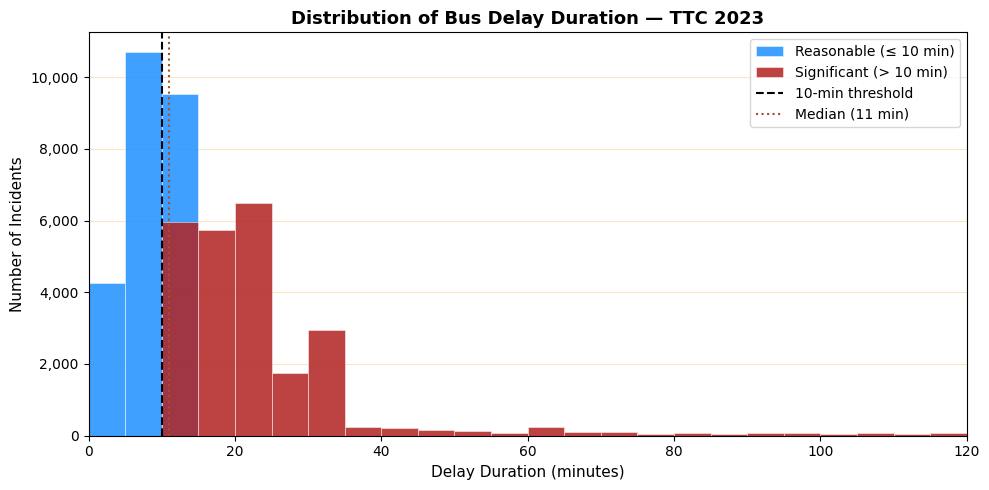

Reasonable delays (≤ 10 min): 24,482 (48.8%)
Significant delays (> 10 min): 25,716 (51.2%)
Skewness: 10.59


In [12]:
# Create target variable
df['Delay_Over_10'] = (df['Min Delay'] > 10).astype(int)

# Cap at 120 min for readability (998 min max is a visual outlier)
CAP = 120
df_viz = df[df['Min Delay'] <= CAP]

fig, ax = plt.subplots(figsize=(10, 5))

bins = np.arange(0, CAP + 5, 5)

ax.hist(df_viz[df_viz['Delay_Over_10'] == 0]['Min Delay'],
        bins=bins, color='dodgerblue', alpha=0.85,
        label='Reasonable (≤ 10 min)', edgecolor='white', linewidth=0.4)

ax.hist(df_viz[df_viz['Delay_Over_10'] == 1]['Min Delay'],
        bins=bins, color='firebrick', alpha=0.85,
        label='Significant (> 10 min)', edgecolor='white', linewidth=0.4)
# Threshold + median reference lines
ax.axvline(x=10, color='black', linestyle='--', linewidth=1.5, label='10-min threshold')
ax.axvline(x=df_viz['Min Delay'].median(), color='sienna', linestyle=':',
           linewidth=1.5, label=f"Median ({df_viz['Min Delay'].median():.0f} min)")

ax.set_title('Distribution of Bus Delay Duration — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Delay Duration (minutes)', fontsize=11)
ax.set_ylabel('Number of Incidents', fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, CAP)
ax.legend(fontsize=10)
ax.grid(axis='y', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)


plt.tight_layout()
plt.show()

print(f"Reasonable delays (≤ 10 min): {(df['Delay_Over_10']==0).sum():,} ({(df['Delay_Over_10']==0).mean()*100:.1f}%)")
print(f"Significant delays (> 10 min): {(df['Delay_Over_10']==1).sum():,} ({(df['Delay_Over_10']==1).mean()*100:.1f}%)")
print(f"Skewness: {df['Min Delay'].skew():.2f}")

B2. % of Significant vs Reasonable Delays by Incident Type

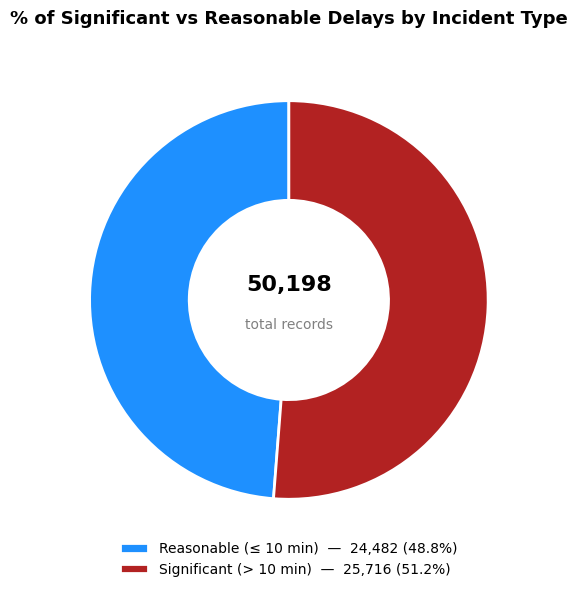

In [13]:
counts = df['Delay_Over_10'].value_counts().sort_index()
labels = ['Reasonable\n(≤ 10 min)', 'Significant\n(> 10 min)']
colors = ['dodgerblue', 'firebrick']
pcts = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts = ax.pie(
    counts,
    labels=None,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

# Center text: total count
ax.text(0, 0.08, f'{counts.sum():,}', ha='center', va='center',
        fontsize=16, fontweight='bold')
ax.text(0, -0.12, 'total records', ha='center', va='center',
        fontsize=10, color='gray')

# Legend with count + percentage
legend_labels = [f'{lbl.replace(chr(10), " ")}  —  {cnt:,} ({pct:.1f}%)'
                 for lbl, cnt, pct in zip(labels, counts, pcts)]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=10, frameon=False)

ax.set_title('% of Significant vs Reasonable Delays by Incident Type',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

B3. Average Delay Duration By Incident Type

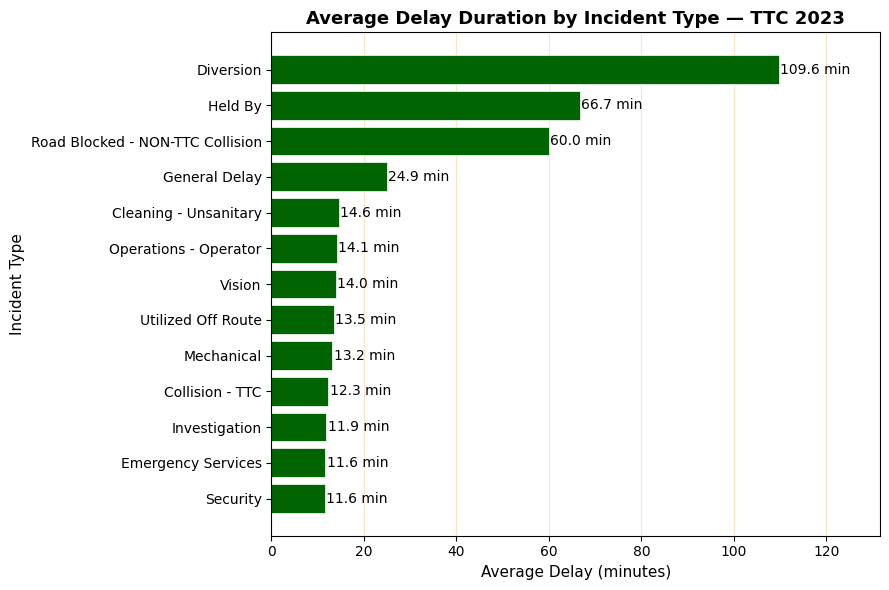

In [14]:
avg_delay = df.groupby('Incident')['Min Delay'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(avg_delay.index, avg_delay.values,
               color='darkgreen', edgecolor='white', linewidth=0.5)

# Annotate each bar with the value
for bar, val in zip(bars, avg_delay.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} min', va='center', fontsize=10)

ax.set_title('Average Delay Duration by Incident Type — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Delay (minutes)', fontsize=11)
ax.set_ylabel('Incident Type', fontsize=11)
ax.set_xlim(0, avg_delay.max() * 1.2)
ax.grid(axis='x', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

B4. % of Significant vs Reasonable Delays by Incident Type


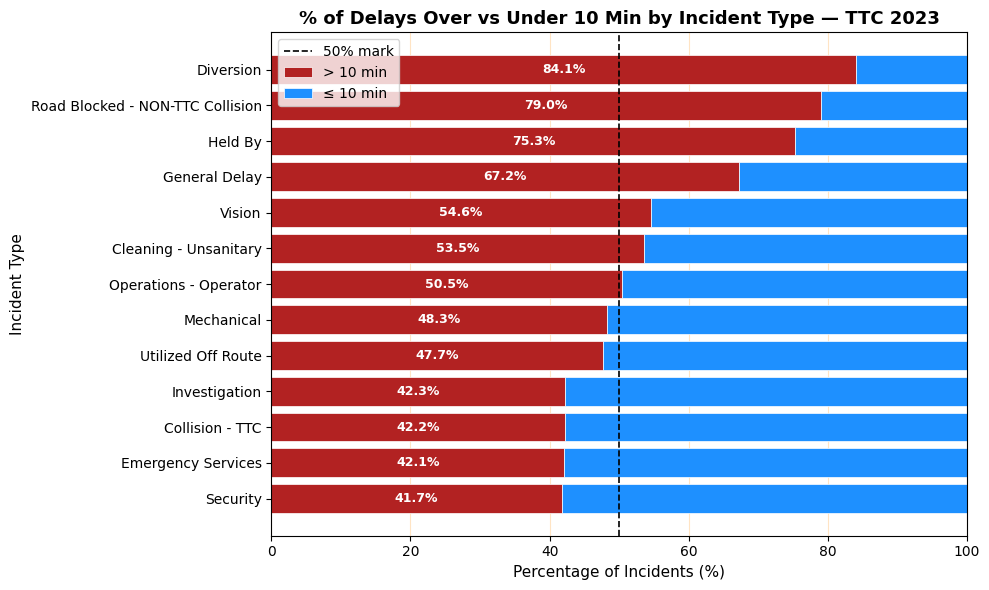

In [15]:
pct_over = df.groupby('Incident')['Delay_Over_10'].mean() * 100
pct_under = 100 - pct_over

# Sort by % over 10 (significant delay) min
pct_over = pct_over.sort_values(ascending=True)
pct_under = pct_under.reindex(pct_over.index)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(pct_over.index, pct_over.values,
        color='firebrick', edgecolor='white', linewidth=0.5, label='> 10 min')
ax.barh(pct_under.index, pct_under.values,
        left=pct_over.values,
        color='dodgerblue', edgecolor='white', linewidth=0.5, label='≤ 10 min')


for i, val in enumerate(pct_over.values):
    ax.text(val / 2, i, f'{val:.1f}%',
            va='center', ha='center', fontsize=9, color='white', fontweight='bold')

ax.axvline(x=50, color='black', linestyle='--', linewidth=1.2, label='50% mark')

ax.set_title('% of Delays Over vs Under 10 Min by Incident Type — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of Incidents (%)', fontsize=11)
ax.set_ylabel('Incident Type', fontsize=11)
ax.set_xlim(0, 100)
ax.legend(fontsize=10)
ax.grid(axis='x', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

B5. Count of incidents by type

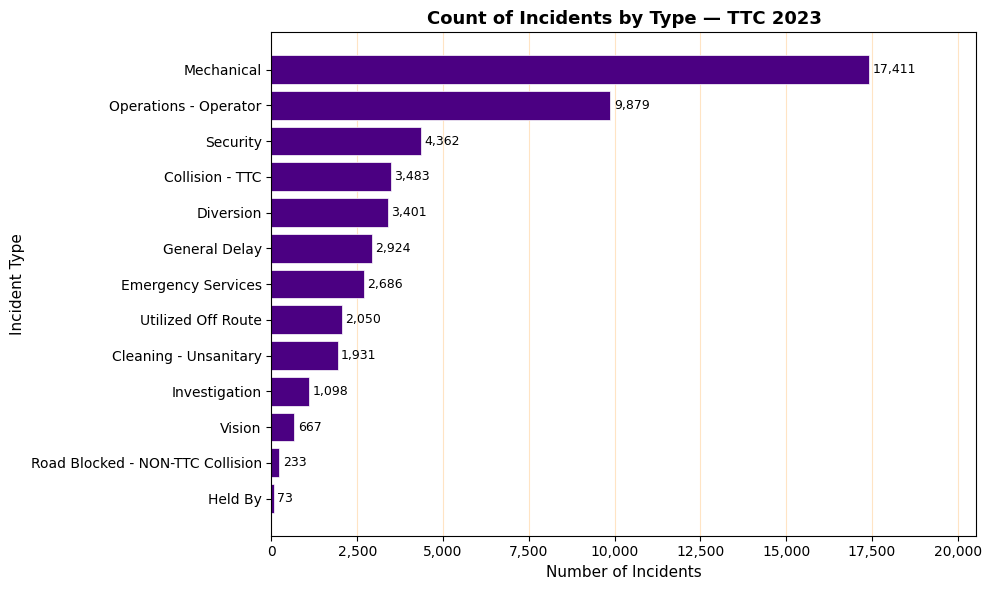

In [16]:
incident_counts = df['Incident'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(incident_counts.index, incident_counts.values,
               color='indigo', edgecolor='white', linewidth=0.5)


for bar, val in zip(bars, incident_counts.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Count of Incidents by Type — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Incidents', fontsize=11)
ax.set_ylabel('Incident Type', fontsize=11)
ax.set_xlim(0, incident_counts.max() * 1.18)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

B6.Delay Count by Hour of Day

Delay Count by Hour of Day — TTC 2023
  00:00  |  997
  01:00  |  663
  02:00  |  716
  03:00  |  608
  04:00  |  807
  05:00  |  1,793
  06:00  |  2,381
  07:00  |  2,277  ← morning rush
  08:00  |  2,212  ← morning rush
  09:00  |  2,414  ← morning rush
  10:00  |  2,262
  11:00  |  2,243
  12:00  |  2,405
  13:00  |  2,674
  14:00  |  3,083
  15:00  |  3,579
  16:00  |  3,609  ← evening rush
  17:00  |  3,548  ← evening rush
  18:00  |  3,213  ← evening rush
  19:00  |  2,247
  20:00  |  1,902
  21:00  |  1,775
  22:00  |  1,478
  23:00  |  1,312
  Total  |  50,198


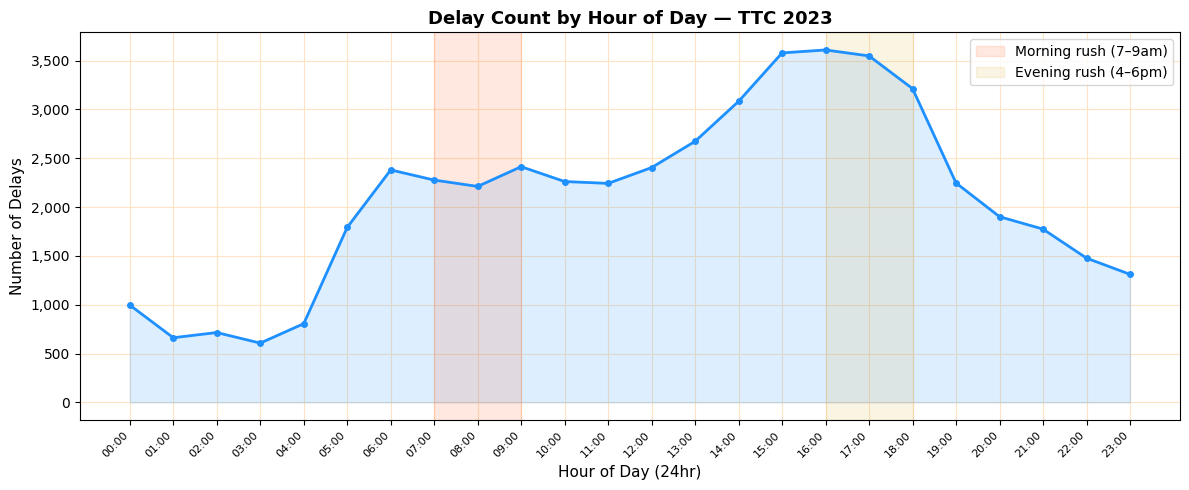

In [17]:
df['Hour'] = df['DateTime'].dt.hour

count_by_hour = df.groupby('Hour')['Min Delay'].count()

# Print
print("Delay Count by Hour of Day — TTC 2023")
print("=" * 40)
for hour, count in count_by_hour.items():
    label = f"{hour:02d}:00"
    rush = ""
    if 7 <= hour <= 9:
        rush = "  ← morning rush"
    elif 16 <= hour <= 18:
        rush = "  ← evening rush"
    print(f"  {label}  |  {count:,}{rush}")
print("=" * 40)
print(f"  Total  |  {count_by_hour.sum():,}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(count_by_hour.index, count_by_hour.values,
        color='dodgerblue', linewidth=2, marker='o', markersize=4)

ax.fill_between(count_by_hour.index, count_by_hour.values,
                alpha=0.15, color='dodgerblue')

ax.axvspan(7, 9, alpha=0.12, color='orangered', label='Morning rush (7–9am)')
ax.axvspan(16, 18, alpha=0.12, color='goldenrod', label='Evening rush (4–6pm)')

ax.set_title('Delay Count by Hour of Day — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (24hr)', fontsize=11)
ax.set_ylabel('Number of Delays', fontsize=11)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=10)
ax.grid(color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

B7. Average Delay by Hour of Day

Average Delay Duration by Hour of Day — TTC 2023
  00:00  |  20.17 min
  01:00  |  19.11 min
  02:00  |  29.78 min
  03:00  |  23.47 min
  04:00  |  21.05 min
  05:00  |  18.95 min
  06:00  |  21.59 min
  07:00  |  22.95 min  ← morning rush
  08:00  |  22.72 min  ← morning rush
  09:00  |  20.07 min  ← morning rush
  10:00  |  23.92 min
  11:00  |  23.78 min
  12:00  |  18.55 min
  13:00  |  19.31 min
  14:00  |  19.86 min
  15:00  |  20.33 min
  16:00  |  17.86 min  ← evening rush
  17:00  |  17.19 min  ← evening rush
  18:00  |  18.45 min  ← evening rush
  19:00  |  20.35 min
  20:00  |  21.39 min
  21:00  |  22.38 min
  22:00  |  23.86 min
  23:00  |  23.78 min
  Overall avg  |  21.29 min


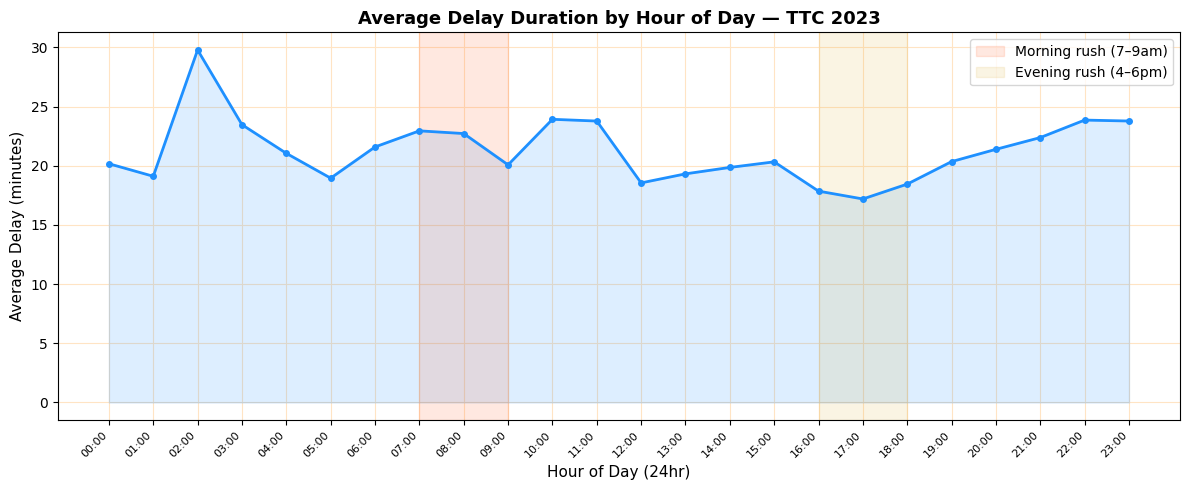

In [18]:
df['Hour'] = df['DateTime'].dt.hour

avg_by_hour = df.groupby('Hour')['Min Delay'].mean()

# Print the data
print("Average Delay Duration by Hour of Day — TTC 2023")
print("=" * 40)
for hour, avg in avg_by_hour.items():
    label = f"{hour:02d}:00"
    rush = ""
    if 7 <= hour <= 9:
        rush = "  ← morning rush"
    elif 16 <= hour <= 18:
        rush = "  ← evening rush"
    print(f"  {label}  |  {avg:.2f} min{rush}")
print("=" * 40)
print(f"  Overall avg  |  {avg_by_hour.mean():.2f} min")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(avg_by_hour.index, avg_by_hour.values,
        color='dodgerblue', linewidth=2, marker='o', markersize=4)

ax.fill_between(avg_by_hour.index, avg_by_hour.values,
                alpha=0.15, color='dodgerblue')

ax.axvspan(7, 9, alpha=0.12, color='orangered', label='Morning rush (7–9am)')
ax.axvspan(16, 18, alpha=0.12, color='goldenrod', label='Evening rush (4–6pm)')

ax.set_title('Average Delay Duration by Hour of Day — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (24hr)', fontsize=11)
ax.set_ylabel('Average Delay (minutes)', fontsize=11)
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10)
ax.grid(color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

B8. Delay Duration by Days of Week

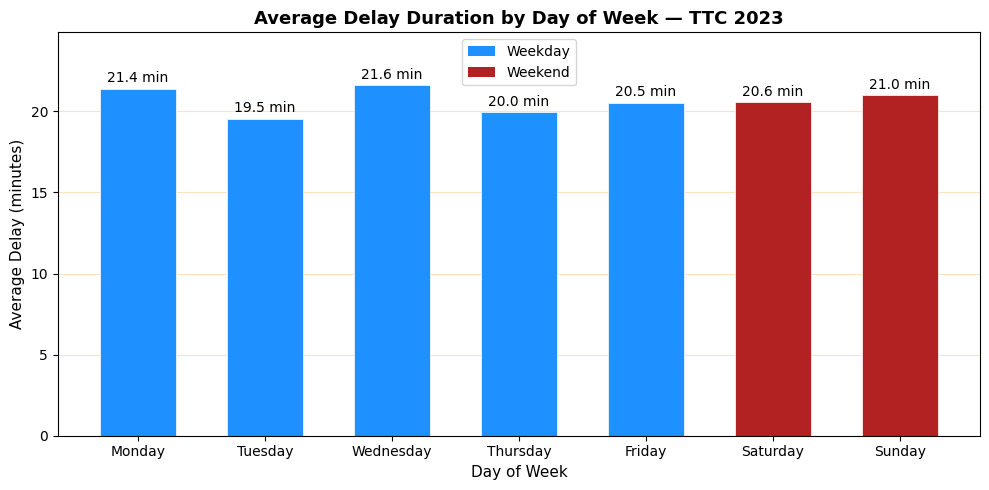

In [19]:
# Ordered days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_day = df.groupby('Day')['Min Delay'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['firebrick' if day in ['Saturday', 'Sunday'] else 'dodgerblue' for day in day_order]

bars = ax.bar(avg_by_day.index, avg_by_day.values,
              color=colors, edgecolor='white', linewidth=0.5, width=0.6)

for bar, val in zip(bars, avg_by_day.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{val:.1f} min', ha='center', va='bottom', fontsize=10)

# Custom legend for weekday vs weekend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='dodgerblue', label='Weekday'),
                   Patch(facecolor='firebrick', label='Weekend')]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_title('Average Delay Duration by Day of Week — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=11)
ax.set_ylabel('Average Delay (minutes)', fontsize=11)
ax.set_ylim(0, avg_by_day.max() * 1.15)
ax.grid(axis='y', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

B9. Delay Heatmap: hour × day of week

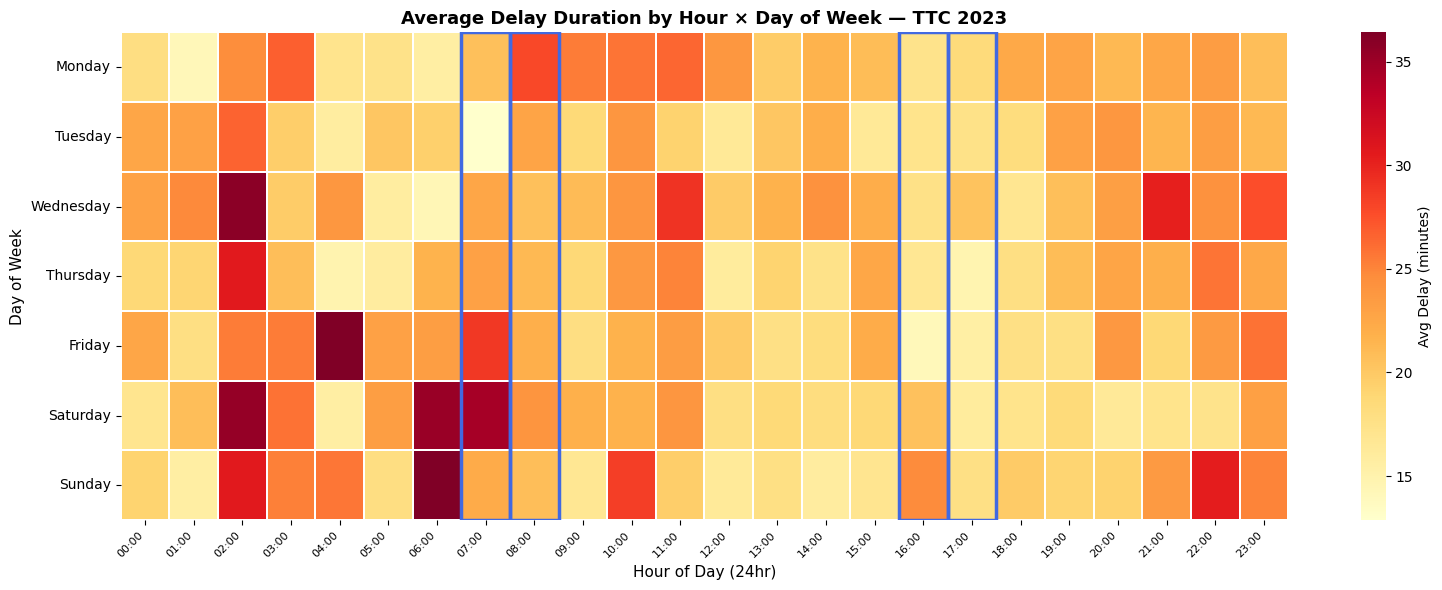

In [20]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['Day', 'Hour'])['Min Delay'].mean().unstack(level='Hour')
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(heatmap_data,
            cmap='YlOrRd',
            annot=False,
            linewidths=0.3,
            linecolor='white',
            cbar_kws={'label': 'Avg Delay (minutes)'},
            ax=ax)

# Highlight rush hour columns
for hour in [7, 8, 16, 17]:
    ax.add_patch(plt.Rectangle((hour, 0), 1, 7,
                 fill=False, edgecolor='royalblue', linewidth=2.5))

ax.set_title('Average Delay Duration by Hour × Day of Week — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (24hr)', fontsize=11)
ax.set_ylabel('Day of Week', fontsize=11)
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(day_order, rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

B10. Top 10 Routes by Delay Count

Top 10 Routes by Delay Count — TTC 2023
  Route 32  |  1,736 delays
  Route 36  |  1,569 delays
  Route 52  |  1,213 delays
  Route 29  |  1,201 delays
  Route 35  |  1,176 delays
  Route 7  |  1,116 delays
  Route 54  |  888 delays
  Route 41  |  880 delays
  Route 47  |  876 delays
  Route 63  |  864 delays
  Total  |  11,519 delays


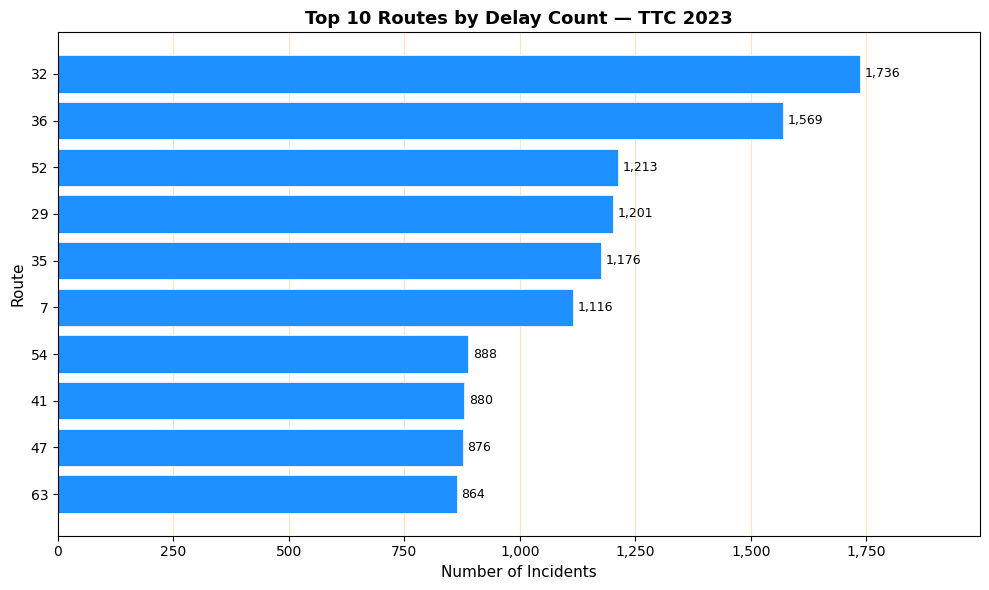

In [21]:
top10_count = df.groupby('Route')['Min Delay'].count().sort_values(ascending=False).head(10).sort_values(ascending=True)

# Print
print("Top 10 Routes by Delay Count — TTC 2023")
print("=" * 40)
for route, count in top10_count.sort_values(ascending=False).items():
    print(f"  Route {route}  |  {count:,} delays")
print("=" * 40)
print(f"  Total  |  {top10_count.sum():,} delays")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10_count.index.astype(str), top10_count.values,
               color='dodgerblue', edgecolor='white', linewidth=0.5)

# Annotate each bar
for bar, val in zip(bars, top10_count.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 10 Routes by Delay Count — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Incidents', fontsize=11)
ax.set_ylabel('Route', fontsize=11)
ax.set_xlim(0, top10_count.max() * 1.15)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

B11. Top 10 Routes by Avg Delay Duration

Top 10 Routes by Average Delay Duration — TTC 2023
  Route 55  |  135.68 min avg delay
  Route 337  |  94.76 min avg delay
  Route 121  |  83.64 min avg delay
  Route 33  |  75.23 min avg delay
  Route 77  |  69.17 min avg delay
  Route 28  |  65.82 min avg delay
  Route 167  |  60.11 min avg delay
  Route 74  |  58.79 min avg delay
  Route 13  |  57.60 min avg delay
  Route 162  |  55.78 min avg delay
  Overall avg  |  20.65 min


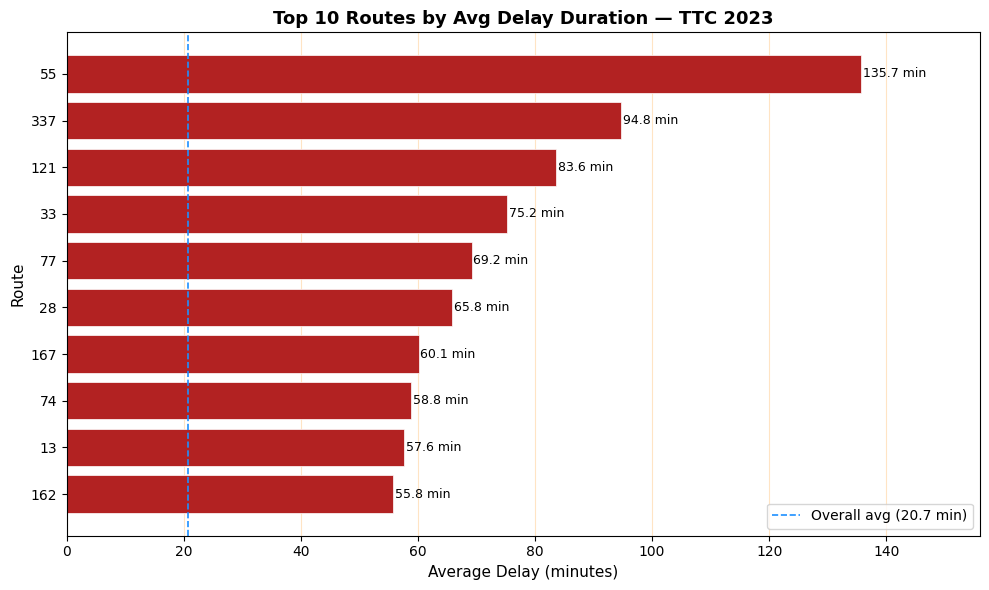

In [22]:
avg_by_route = df.groupby('Route')['Min Delay'].mean().sort_values(ascending=False).head(10).sort_values(ascending=True)

# Print
print("Top 10 Routes by Average Delay Duration — TTC 2023")
print("=" * 45)
for route, avg in avg_by_route.sort_values(ascending=False).items():
    print(f"  Route {route}  |  {avg:.2f} min avg delay")
print("=" * 45)
print(f"  Overall avg  |  {df['Min Delay'].mean():.2f} min")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(avg_by_route.index.astype(str), avg_by_route.values,
               color='firebrick', edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, avg_by_route.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} min', va='center', fontsize=9)

ax.axvline(x=df['Min Delay'].mean(), color='dodgerblue', linestyle='--',
           linewidth=1.2, label=f'Overall avg ({df["Min Delay"].mean():.1f} min)')

ax.set_title('Top 10 Routes by Avg Delay Duration — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Delay (minutes)', fontsize=11)
ax.set_ylabel('Route', fontsize=11)
ax.set_xlim(0, avg_by_route.max() * 1.15)
ax.legend(fontsize=10)
ax.grid(axis='x', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

B12. Delay Duration vs Gap Between Buses

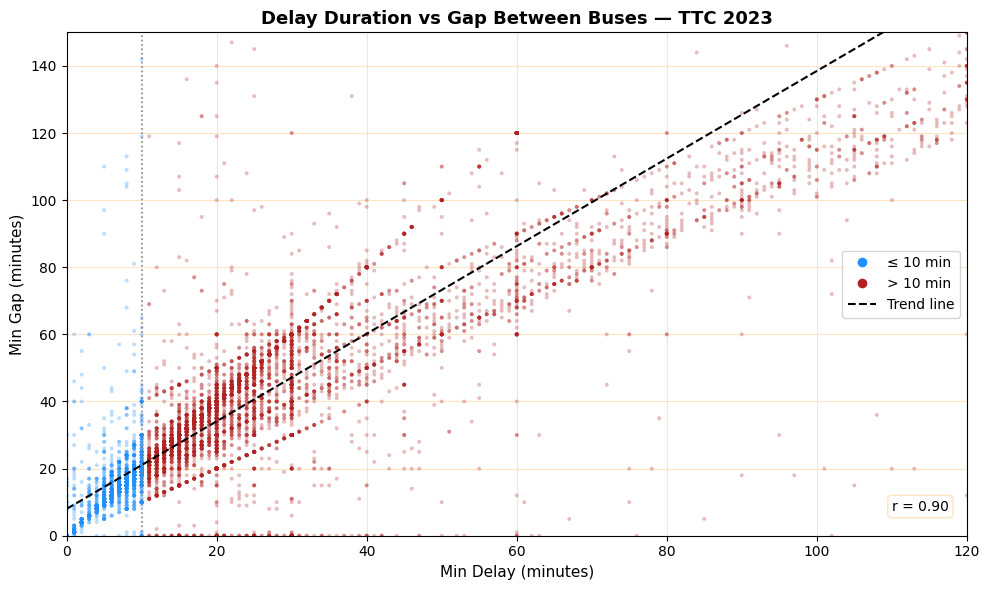

Correlation: 0.90


In [23]:
# Cap both axes for readability
CAP_DELAY = 120
CAP_GAP = 150
df_scatter = df[(df['Min Delay'] <= CAP_DELAY) & (df['Min Gap'] <= CAP_GAP)]

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df_scatter['Min Delay'], df_scatter['Min Gap'],
                     c=df_scatter['Delay_Over_10'].map({0: 'dodgerblue', 1: 'firebrick'}),
                     alpha=0.3, s=8, linewidths=0)

# Trend line
z = np.polyfit(df_scatter['Min Delay'], df_scatter['Min Gap'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, CAP_DELAY, 200)
ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--', label='Trend line')

ax.axvline(x=10, color='gray', linestyle=':', linewidth=1.2, label='10-min threshold')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='dodgerblue',
                          markersize=8, label='≤ 10 min'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='firebrick',
                          markersize=8, label='> 10 min'),
                   Line2D([0], [0], color='black', linestyle='--', label='Trend line')]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_title('Delay Duration vs Gap Between Buses — TTC 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Min Delay (minutes)', fontsize=11)
ax.set_ylabel('Min Gap (minutes)', fontsize=11)
ax.set_xlim(0, CAP_DELAY)
ax.set_ylim(0, CAP_GAP)
ax.grid(color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

corr = df_scatter[['Min Delay', 'Min Gap']].corr().iloc[0, 1]
ax.text(0.98, 0.05, f'r = {corr:.2f}', transform=ax.transAxes,
        ha='right', fontsize=10, color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='bisque'))

plt.tight_layout()
plt.show()
print(f"Correlation: {corr:.2f}")

B13. Percentage Over-10 Min: Weekend vs Weekday

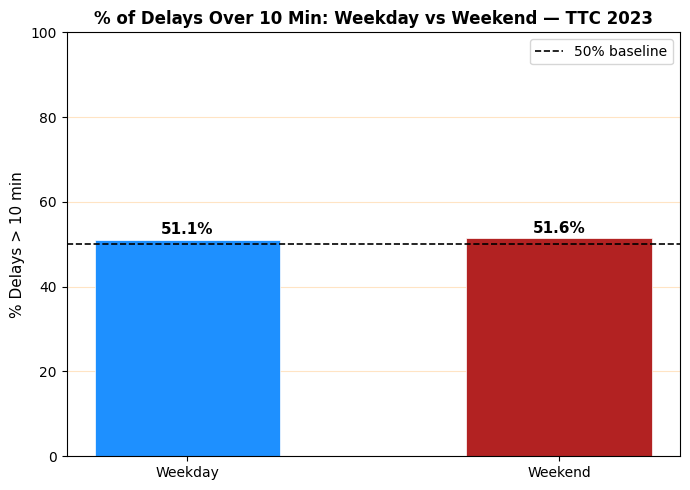

Weekday: 51.1% of delays exceed 10 min
Weekend: 51.6% of delays exceed 10 min


In [24]:
df['Is_Weekend'] = df['Day'].isin(['Saturday', 'Sunday']).astype(int)
weekend_pct = df.groupby('Is_Weekend')['Delay_Over_10'].mean() * 100
weekend_pct.index = weekend_pct.index.map({0: 'Weekday', 1: 'Weekend'})

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['dodgerblue', 'firebrick']
bars = ax.bar(weekend_pct.index, weekend_pct.values,
              color=colors, edgecolor='white', linewidth=0.5, width=0.5)

# Annotate each bar
for bar, val in zip(bars, weekend_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=50, color='black', linestyle='--', linewidth=1.2, label='50% baseline')

ax.set_title('% of Delays Over 10 Min: Weekday vs Weekend — TTC 2023',
             fontsize=12, fontweight='bold')
ax.set_ylabel('% Delays > 10 min', fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.grid(axis='y', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"Weekday: {weekend_pct['Weekday']:.1f}% of delays exceed 10 min")
print(f"Weekend: {weekend_pct['Weekend']:.1f}% of delays exceed 10 min")

###**PART C: MM Modeling**

C1. Feature Engineering & Preprocessing

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [26]:
# For Feature Engineering

# Rush Hour Indicator (from EDA)
df['Rush_Hour'] = df['Hour'].apply(lambda h: 1 if h in range (7, 10) or h in range (16, 19) else 0)

# Encode Weekend as binary
df['Is_Weekend'] = df['Day'].isin(['Saturday', 'Sunday']).astype(int)

# Selecting features
features = ['Hour', 'Rush_Hour', 'Is_Weekend', 'Incident', 'Day', 'Route']
target = 'Delay_Over_10'

df_model = df[features + [target]].copy()

In [27]:
# To encode Categorial Variables
le_incident = LabelEncoder()
le_day = LabelEncoder()
le_route = LabelEncoder()

df_model['Incident_enc'] = le_incident.fit_transform(df_model['Incident'])
df_model['Day_enc'] = le_day.fit_transform(df_model['Day'])
df_model['Route_enc'] = le_route.fit_transform(df_model['Route'].astype(str))

# Final feature set
X = df_model[['Hour', 'Rush_Hour', 'Is_Weekend', 'Incident_enc', 'Day_enc', 'Route_enc']]
y = df_model[target]

print("Class distrbution:\n", y.value_counts())
print("Feature matrix shape:", X.shape)

Class distrbution:
 Delay_Over_10
1    25716
0    24482
Name: count, dtype: int64
Feature matrix shape: (50198, 6)


C2. Train/Test Split & Train RF

In [28]:
# We will be doing a 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RF
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Training complete")
print(f"Training samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

Training complete
Training samples: 40158 | Test samples: 10040


C3. Evaluating the Model

Accuracy:
0.7214

Classification Report:
              precision    recall  f1-score   support

   <= 10 min       0.72      0.71      0.72      4961
    > 10 min       0.72      0.73      0.73      5079

    accuracy                           0.72     10040
   macro avg       0.72      0.72      0.72     10040
weighted avg       0.72      0.72      0.72     10040



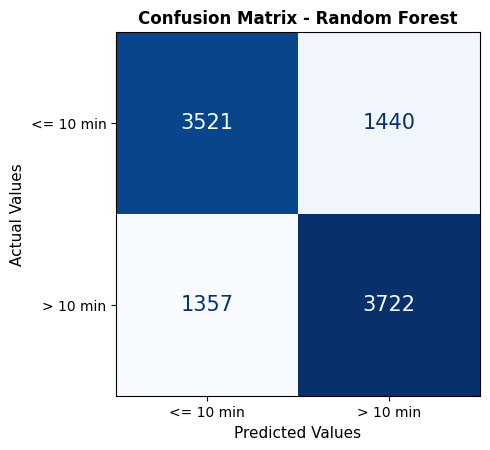

In [29]:
y_pred = rf.predict(X_test)

print("Accuracy:")
print(f"{accuracy_score(y_test, y_pred):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<= 10 min', '> 10 min']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<= 10 min', '> 10 min'])
fig, ax = plt.subplots(figsize=(5, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
for text in ax.texts:
    text.set_fontsize(15)
ax.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Values', fontsize=11)
ax.set_xlabel('Predicted Values', fontsize=11)
plt.tight_layout()
plt.show()

C4. Feature Importance

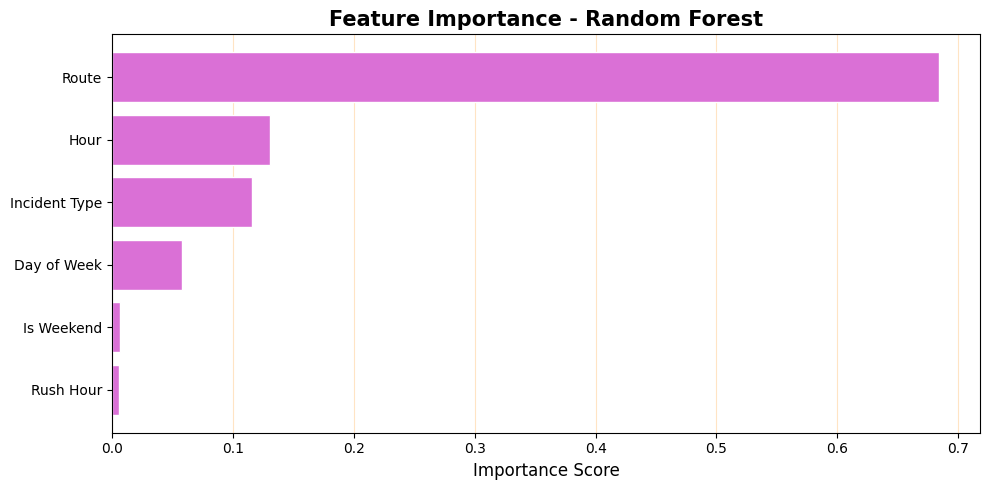

In [30]:
feature_names = ['Hour', 'Rush Hour', 'Is Weekend', 'Incident Type', 'Day of Week', 'Route']
importances = rf.feature_importances_
sorted_idx = importances.argsort()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color='orchid', edgecolor='white')
ax.set_title('Feature Importance - Random Forest', fontsize=15, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.grid(axis='x', color='bisque', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()